### EDA
check Data :
- Measures of Central Tendency(Mean、Median、Mode)
- Dispersion or variabillity(Range、Variance、Standard Deviation、IQR、CV)
- shape(distribution: skewness, kurtosis)

1. Structure         → shape / dtypes / head / info
2. Duplicates        → duplicated().sum()
3. Missing Values    → NaN ratio, missing pattern (msno.matrix)
4. Distribution      → describe() + 每個 feature 的直方圖/KDE
5. Outliers          → IQR or Z-score，boxplot 輔助
6. Cardinality       → categorical unique counts
7. Class Balance     → target 分佈（你的 category_balance）
8. Correlation       → feature vs feature heatmap
9. Target Relation   → feature vs target（bivariate analysis）

In [7]:
import seaborn as sns

df = sns.load_dataset('titanic')
print(df.head())
print(f"shape:{df.shape}")


   survived  pclass     sex   age  ...  deck  embark_town  alive  alone
0         0       3    male  22.0  ...   NaN  Southampton     no  False
1         1       1  female  38.0  ...     C    Cherbourg    yes  False
2         1       3  female  26.0  ...   NaN  Southampton    yes   True
3         1       1  female  35.0  ...     C  Southampton    yes  False
4         0       3    male  35.0  ...   NaN  Southampton     no   True

[5 rows x 15 columns]
shape:(891, 15)


### 缺值分析

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [17]:
missing_count = df.isnull().sum()
#print(f"missing count:{missing_count}")
missing_rate = missing_count/len(df)*100
print(f"missing rate: {missing_rate}")

missing rate: survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [19]:
import pandas as pd
df_missing = pd.DataFrame({
    'missing_count':missing_count,
    'missing_rate':missing_rate,
})
df_missing=df_missing[
    df_missing['missing_count']>0
    ].sort_values('missing_rate',ascending=True)
df_missing

,missing_count,missing_rate
embarked,2,0.224467
embark_town,2,0.224467
age,177,19.865320
deck,688,77.216611


### note
figsize:
- (8, 4)：寬型，適合barh, time series
- (6, 6)：正方形，適合scatter, heatmap
- (10, 6)：大圖

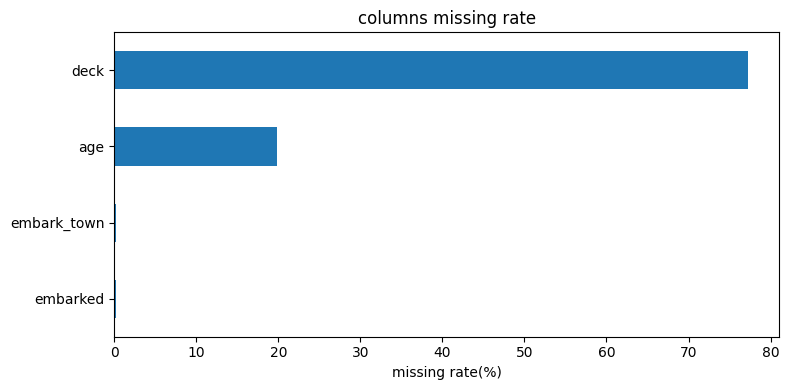

In [20]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4))
df_missing['missing_rate'].plot(kind='barh',ax=ax)
ax.set_title('columns missing rate')
ax.set_xlabel('missing rate(%)')
plt.tight_layout()
plt.show()
